In [1]:
import numpy as np
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import copy as cp
from tqdm import tqdm

In [2]:
total_chains = np.unique([i[:4] for i in np.loadtxt('../3_chains/all_chains.txt', dtype=str)])
total_chains.shape

(421,)

In [3]:
selected = np.loadtxt('../3_chains/selected.txt', dtype=str)

In [4]:
selected.shape

(509,)

In [5]:
trjs = ['apo', 'bound', 'am_open', 'am_closed']

In [6]:
mins = np.zeros((4,selected.shape[0]))
path='2_rmsd_98-136'
for a,trj in enumerate(trjs):
    for b,pdb in tqdm(enumerate(selected)):
        mins[a,b] = np.min(np.loadtxt(f'{path}/{trj}_{pdb}.xvg', comments=['@','#'])[:,1])

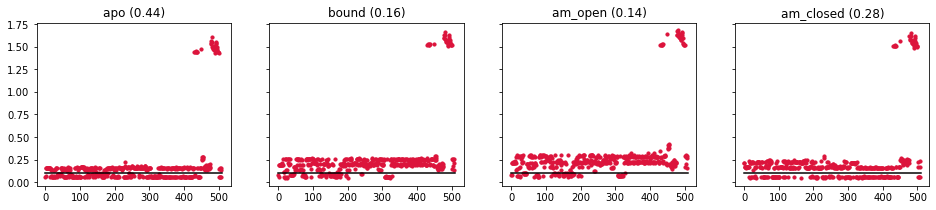

In [18]:
cut=0.1
fig,ax=plt.subplots(1,4, figsize=(16,3), sharex=True, sharey=True)
for a,mini in enumerate(mins):
    ax[a].scatter(range(len(selected)), mini, color='crimson', s=10)
    ax[a].plot([0,len(selected)], [cut, cut], c='black')
    ratio = np.where(mini<=cut)[0].shape[0]/len(mini)
    ax[a].set_title(f'{trjs[a]} ({np.round(ratio,2)})')
plt.show()

In [19]:
np.save('saved_mins/mins_bb_98-136.npy', mins)

509it [17:50,  2.10s/it]
509it [12:14,  1.44s/it]
509it [03:54,  2.17it/s]
509it [03:31,  2.41it/s]


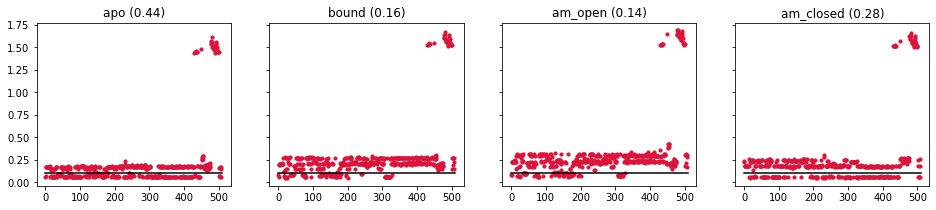

In [20]:
mins = np.zeros((4,selected.shape[0]))
path='2_ca_rmsd_98-136'
for a,trj in enumerate(trjs):
    for b,pdb in tqdm(enumerate(selected)):
        mins[a,b] = np.min(np.loadtxt(f'{path}/{trj}_{pdb}.xvg', comments=['@','#'])[:,1])
    #
cut=0.1
fig,ax=plt.subplots(1,4, figsize=(16,3), sharex=True, sharey=True)
for a,mini in enumerate(mins):
    ax[a].scatter(range(len(selected)), mini, color='crimson', s=10)
    ax[a].plot([0,len(selected)], [cut, cut], c='black')
    ratio = np.where(mini<=cut)[0].shape[0]/len(mini)
    ax[a].set_title(f'{trjs[a]} ({np.round(ratio,2)})')
plt.show()
#
np.save('saved_mins/mins_ca_98-136.npy', mins)

509it [18:23,  2.17s/it]
509it [12:52,  1.52s/it]
509it [03:04,  2.76it/s]
509it [03:25,  2.48it/s]


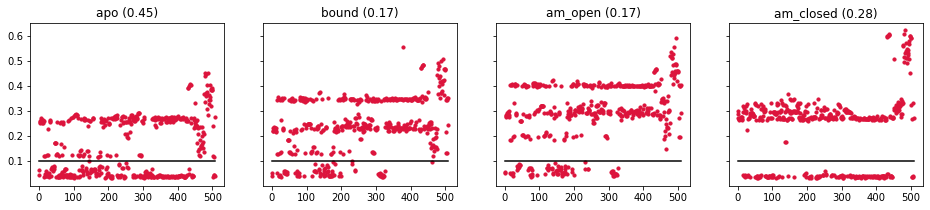

In [21]:
mins = np.zeros((4,selected.shape[0]))
path='3_rmsd_106-115'
for a,trj in enumerate(trjs):
    for b,pdb in tqdm(enumerate(selected)):
        mins[a,b] = np.min(np.loadtxt(f'{path}/{trj}_{pdb}.xvg', comments=['@','#'])[:,1])
    #
cut=0.1
fig,ax=plt.subplots(1,4, figsize=(16,3), sharex=True, sharey=True)
for a,mini in enumerate(mins):
    ax[a].scatter(range(len(selected)), mini, color='crimson', s=10)
    ax[a].plot([0,len(selected)], [cut, cut], c='black')
    ratio = np.where(mini<=cut)[0].shape[0]/len(mini)
    ax[a].set_title(f'{trjs[a]} ({np.round(ratio,2)})')
plt.show()
#
np.save('saved_mins/mins_bb_106-115.npy', mins)

509it [17:52,  2.11s/it]
509it [12:08,  1.43s/it]
509it [03:24,  2.49it/s]
509it [03:06,  2.73it/s]


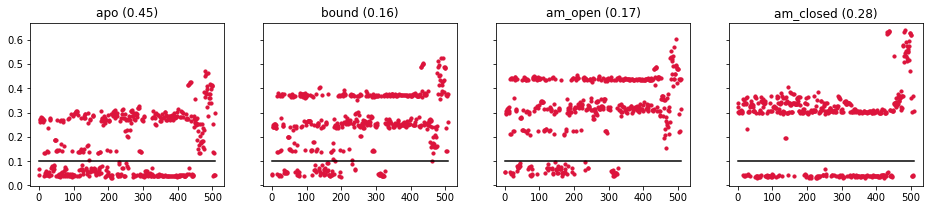

In [22]:
mins = np.zeros((4,selected.shape[0]))
path='3_ca_rmsd_106-115'
for a,trj in enumerate(trjs):
    for b,pdb in tqdm(enumerate(selected)):
        mins[a,b] = np.min(np.loadtxt(f'{path}/{trj}_{pdb}.xvg', comments=['@','#'])[:,1])
    #
cut=0.1
fig,ax=plt.subplots(1,4, figsize=(16,3), sharex=True, sharey=True)
for a,mini in enumerate(mins):
    ax[a].scatter(range(len(selected)), mini, color='crimson', s=10)
    ax[a].plot([0,len(selected)], [cut, cut], c='black')
    ratio = np.where(mini<=cut)[0].shape[0]/len(mini)
    ax[a].set_title(f'{trjs[a]} ({np.round(ratio,2)})')
plt.show()
#
np.save('saved_mins/mins_ca_106-115.npy', mins)

### final

### rmsd backbone L4

In [6]:
mins = np.load('saved_mins/mins_bb_106-115.npy')[0]

In [7]:
mins.shape

(509,)

In [8]:
info = np.loadtxt('../3_chains/all_chains.info', comments=['@'], dtype=str)

In [9]:
info.shape

(572, 4)

In [10]:
selected.shape

(509,)

In [11]:
info = np.array([i for i in info if i[0] in selected])
info.shape

(509, 4)

In [12]:
info

array([['1byq_A', 'd', 'o', 'n'],
       ['1osf_A', 'b', 'o', 'n'],
       ['1uy6_A', 'd', 'h', 'n'],
       ...,
       ['8w8k_B', 'a', 'l', 'n'],
       ['8x2r_A', 'a', 'i', 'n'],
       ['9auu_A', 'd', 'h', 'n']], dtype='<U8')

In [13]:
{i:np.where(info[:,1]==i)[0].shape[0] for i in np.unique(info[:,1])}

{'a': 73, 'b': 8, 'd': 400, 'o': 28}

In [14]:
markers = {'a':'o', 'b':'s', 'd':'P', 'o':'v'}
markers= [markers[m] for m in info[:,1]]

In [15]:
{i:np.where(info[:,2]==i)[0].shape[0] for i in np.unique(info[:,2])}

{'e': 31, 'h': 188, 'i': 146, 'l': 60, 'o': 84}

In [16]:
colors = {'e':'red', 'h':'dodgerblue', 'i':'green', 'l':'pink', 'o':'blue'}
colors = [colors[c] for c in info[:,2]]

In [17]:
np.array(mt.colors.to_rgb('pink'))*255

array([255., 192., 203.])

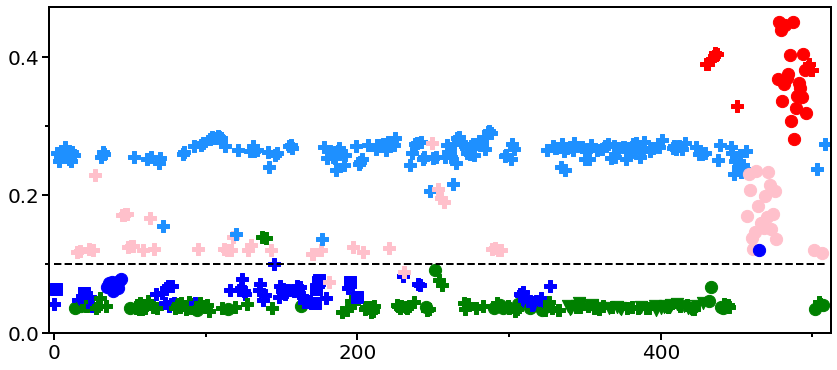

In [22]:
fig,ax=plt.subplots(1, figsize=(14,6))
for a,m in enumerate(mins):
    ax.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
ax.plot([0,len(mins)], [0.1,0.1], '--', c='black', lw=2)
ax.set_xlim(-3,512)
ax.set_xticks([0,200,400])
ax.set_ylim(0,)
ax.set_yticks([0,0.2,0.4])
ax.tick_params(labelsize=20, width=2, length=7)
ax.spines[:].set_linewidth(2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_mins/pdbs_bb_l4_apo.pdf')
plt.show()

In [30]:
np.where(mins<=0.1)[0].shape

(228,)

Observations:<br>
excited state (red color) not observed at all (>0.3) <br>
<br>
helical conformations (dodgerblue) are also not observed (0.2-0.3) <br>
but some helical conformations have low rmsd (<0.3, 2xhr_A, 3bmy_A, 3wha_B), checked - not wrongly assigned <br>
<br>
loop-in conformations (green) are in simulations (<0.1) <br>
but few are (>0.1, 3k99_A, 3k99_D), checked - not wrongly assigned <br>
<br>
loop-out conformations (blue) are in simulations (<0.1) <br>
but one is (>0.1, 8b7i_A9), its nearby only <br>
<br>

In [23]:
mins = np.load('saved_mins/mins_bb_106-115.npy')[1]
info = np.loadtxt('../3_chains/all_chains.info', comments=['@'], dtype=str)
info = np.array([i for i in info if i[0] in selected])
print(info.shape, mins.shape)

(509, 4) (509,)


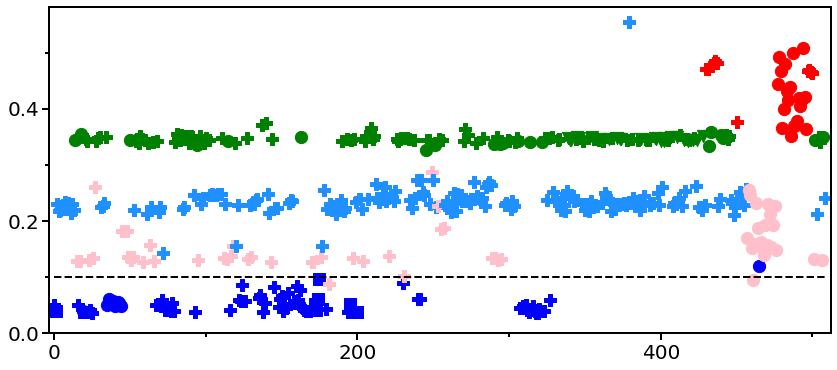

In [27]:
fig,ax=plt.subplots(1, figsize=(14,6))
for a,m in enumerate(mins):
    ax.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
ax.plot([0,len(mins)], [0.1,0.1], '--', c='black', lw=2)
ax.set_xlim(-3,512)
ax.set_xticks([0,200,400])
ax.set_ylim(0,)
ax.set_yticks([0,0.2,0.4])
ax.tick_params(labelsize=20, width=2, length=7)
ax.spines[:].set_linewidth(2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_mins/pdbs_bb_l4_bound.pdf')
plt.show()

In [28]:
np.where(mins<=0.1)[0].shape

(85,)

### longer region (98-136)

In [18]:
mins = np.load('saved_mins/mins_bb_98-136.npy')[0]
info = np.loadtxt('../3_chains/all_chains.info', comments=['@'], dtype=str)
info = np.array([i for i in info if i[0] in selected])
print(info.shape, mins.shape)

(509, 4) (509,)


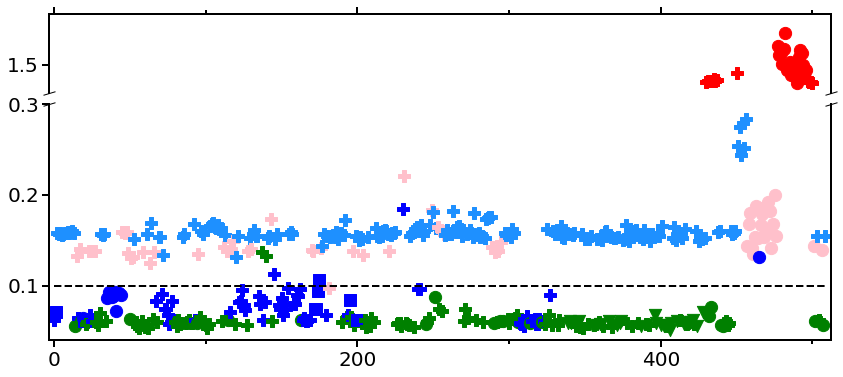

In [41]:
fig,(ax0, ax1) = plt.subplots(2,1, figsize=(14,6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace=0.07)
ax0.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax0.xaxis.tick_top()
ax0.tick_params(labelbottom=False)
d = .3  
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax0.plot([0, 1], [0, 0], transform=ax0.transAxes, **kwargs)
ax1.plot([0, 1], [1, 1], transform=ax1.transAxes, **kwargs)
#
#
for a,m in enumerate(mins):
    if colors[a]=='red':
        ax0.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
    else:
        ax1.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
ax1.plot([0,len(mins)], [0.1,0.1], '--', c='black', lw=2)
#
ax0.set_ylim(1.4,1.68)
ax1.set_xlim(-3,512)
ax1.set_xticks([0,200,400])
ax1.set_yticks([0.1,0.2,0.3])
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax0.set_yticks([1.5])
#
for ax in [ax0,ax1]:
    ax.spines[:].set_linewidth(2)
    ax.tick_params(labelsize=20, length=7, width=2)
    ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_mins/pdbs_bb_longer_apo.pdf')
plt.show()

In [42]:
mins = np.load('saved_mins/mins_bb_98-136.npy')[1]
info = np.loadtxt('../3_chains/all_chains.info', comments=['@'], dtype=str)
info = np.array([i for i in info if i[0] in selected])
print(info.shape, mins.shape)

(509, 4) (509,)


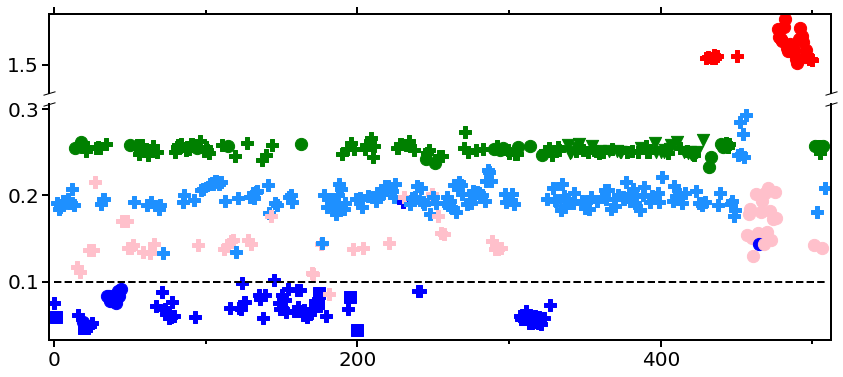

In [43]:
fig,(ax0, ax1) = plt.subplots(2,1, figsize=(14,6), sharex=True, gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace=0.07)
ax0.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax0.xaxis.tick_top()
ax0.tick_params(labelbottom=False)
d = .3  
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax0.plot([0, 1], [0, 0], transform=ax0.transAxes, **kwargs)
ax1.plot([0, 1], [1, 1], transform=ax1.transAxes, **kwargs)
#
#
for a,m in enumerate(mins):
    if colors[a]=='red':
        ax0.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
    else:
        ax1.scatter([a],[m], s=150, c=colors[a], marker=markers[a])
ax1.plot([0,len(mins)], [0.1,0.1], '--', c='black', lw=2)
#
ax0.set_ylim(1.4,1.68)
ax1.set_xlim(-3,512)
ax1.set_xticks([0,200,400])
ax1.set_yticks([0.1,0.2,0.3])
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax0.set_yticks([1.5])
#
for ax in [ax0,ax1]:
    ax.spines[:].set_linewidth(2)
    ax.tick_params(labelsize=20, length=7, width=2)
    ax.tick_params(which='minor', length=4, width=2)
#
plt.savefig('saved_mins/pdbs_bb_longer_bound.pdf')
plt.show()